In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import scipy as sc
from scipy.constants import G
from IPython.display import clear_output
import time

In [18]:
def newton_force(coords1:np.ndarray, mass1:float, coords2:np.ndarray, mass2:float) -> float:
    r = np.linalg.norm(coords1 - coords2)
    F = G*(mass1*mass2)/(r**2)
    return F


In [19]:
def initial_plot(coords:list) -> None:
    fig = plt.figure()
    ax = fig.add_subplot(projection="3d")
    ax.set(xlim3d=(-1.5e11, 1.5e11), xlabel='X')
    ax.set(ylim3d=(-1.5e11, 1.5e11), ylabel='Y')
    ax.set(zlim3d=(-1.5e11, 1.5e11), zlabel='Z')
    for t in coords:
        ax.scatter(t[0], t[1], t[2])
    plt.show()


In [20]:
def leapfrog_integration(coords:list, velocities:list, masses:list, dt) -> tuple:
    # Unpack values    
    x1 = coords[0]
    x2 = coords[1]

    # Calculate unit vectors in the direction of the force
    r1 = (x2 - x1) / np.linalg.norm(x2 - x1)
    r2 = -r1

    m1 = masses[0]
    m2 = masses[1]

    v1 = velocities[0]
    v2 = velocities[1]

    # Calculate the gravitational force magnitude
    F = newton_force(x1, m1, x2, m2)

    # Calculate acceleration magnitudes
    a1 = F / m1
    a2 = F / m2

    # Update velocities using the acceleration (note the dt factor)
    v1_inter = v1 + 0.5 * a1 * dt * r1
    v2_inter = v2 + 0.5 * a2 * dt * r2

    # Update positions using current velocities
    x1_new = x1 + v1_inter * dt
    x2_new = x2 + v2_inter * dt

    # Calculating end velocities
    F_new = newton_force(x1_new, m1, x2_new, m2)

    r1_new = (x2_new - x1_new) / np.linalg.norm(x2_new - x1_new)
    r2_new = -r1_new

    a1_new = F_new / m1
    a2_new = F_new / m2

    v1_new = v1_inter + 0.5 * a1_new * dt * r1_new
    v2_new = v2_inter + 0.5 * a2_new * dt * r2_new

    return [x1_new, x2_new], [v1_new, v2_new]


In [21]:
coords = [np.array([0, 0, 0], dtype=float), np.array([0, 1.5e11, 0], dtype=float)]
velocities = [np.array([0, 0, 0], dtype=float), np.array([0, 0, 30000], dtype=float)]
masses = [1.989e30, 5.972e24]
dt = 1000
# initial_plot(coords)

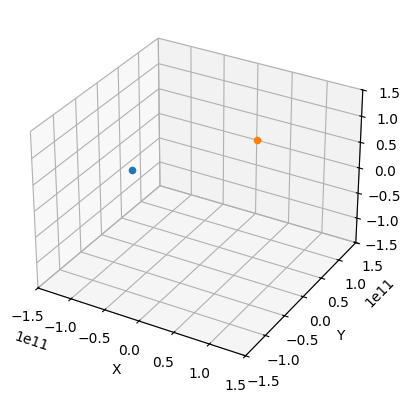

In [35]:
fig = plt.figure()
ax = fig.add_subplot(projection="3d")
ax.set(xlim3d=(-1.5e11, 1.5e11), xlabel='X')
ax.set(ylim3d=(-1.5e11, 1.5e11), ylabel='Y')
ax.set(zlim3d=(-1.5e11, 1.5e11), zlabel='Z')

scats = []
for coord in coords:
    scats.append(ax.scatter(coord[0], coord[1], coord[2]))

scats[0]._offsets3d = ([-1e11], [0], [0])

plt.show()

In [ ]:
def update(frame, masses:list, dt:float):
    global coords, velocities
    coords, velocities = leapfrog_integration(coords, velocities, masses, dt)
    coords_T = np.array(coords).T
    scat.set_offsets(coords_T[0], coords_T[1], coords_T[2])

In [ ]:
coords = [np.array([0, 0, 0], dtype=float), np.array([0, 1.5e11, 0], dtype=float), np.array([0, 1.5e11, 3.84e8], dtype=float)]

traces_list = [[i] for i in coords]

In [40]:
traces_list[0].append(np.array([1, 2, 3]))

In [45]:
np.array(traces_list[0])

array([[0., 0., 0.],
       [1., 2., 3.]])

In [49]:
all_coords = np.array(coords)
margin = 1e10
min_vals = all_coords.min(axis=0) - margin
max_vals = all_coords.max(axis=0) + margin

print(all_coords)
print(min_vals)
print(max_vals)

[[0.00e+00 0.00e+00 0.00e+00]
 [0.00e+00 1.50e+11 0.00e+00]
 [0.00e+00 1.50e+11 3.84e+08]]
[-1.e+10 -1.e+10 -1.e+10]
[1.0000e+10 1.6000e+11 1.0384e+10]
